## EDA 02: Behavioral Resilience of Family Plan Survivors
### 1. Overview
- Customer who maintained their Family plan status through 2025 Oct policy shift demonstrate structurally lower churn risk compared to those migrated to individual plans
- Family --> Family survivors show 8.4% retention advantage, confirmed as statistically significant (ⅹ^2 = 52.97, **p<0.001**)

### 2. Research Hypothesis
- **Core Hypothesis**: Youtube Family Plan policy shift may demonstrate structurally different churn sensitivity patterns compared to single-user or newly migrated segments
- **Data Setup**: August 2025 (baseline) → February 2026 (outcome)
- **Segments**: Family → Family / Family → Individual / Individual → Family / Individual → Individual
- **Expected Pattern**: Family plan continuity correlates with higher retention resilience

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

In [46]:
# Load data
df = pd.read_csv('../data/processed/cleaned_data.csv')
complaints = pd.read_csv('../data/references/youtube_premium_complain.csv')
churn_ts = pd.read_csv('../data/references/youtube_churn.csv')
family_plan = pd.read_csv('../data/references/family_plan.csv')
prices = pd.read_csv('../data/references/youtube_price.csv')

In [47]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5534 entries, 0 to 5533
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5534 non-null   object 
 1   gender            5534 non-null   object 
 2   SeniorCitizen     5534 non-null   int64  
 3   Partner           5534 non-null   object 
 4   Dependents        5534 non-null   object 
 5   tenure            5534 non-null   float64
 6   PhoneService      5534 non-null   object 
 7   MultipleLines     5534 non-null   object 
 8   InternetService   5534 non-null   object 
 9   OnlineSecurity    5534 non-null   object 
 10  OnlineBackup      5534 non-null   object 
 11  DeviceProtection  5534 non-null   object 
 12  TechSupport       5534 non-null   object 
 13  StreamingTV       5534 non-null   object 
 14  StreamingMovies   5534 non-null   object 
 15  Contract          5534 non-null   object 
 16  PaperlessBilling  5534 non-null   object 


In [48]:
df['calculated_tenure'] = (df['TotalCharges'] / df['MonthlyCharges']).round().astype(int)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,calculated_tenure
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,33
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,2
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,44
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2


### 3. Analysis based on 4 Scenarios between Aug 2025 and Feb 2026 on NO Churn

#### 3.1. 4 (Four) Scenarios
- family_aug: Charge change detection — a drop greater than $6 in MonthlyCharges indicates a prior Family Plan discount
- family_feb: Partner == Yes OR Dependents == Yes at observation date
<p>
<table>
    <thead>
        <tr>
            <th>Scenario</th>
            <th>Count</th>
            <th>Description</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td><strong>Family → Family</strong></td>
            <td>2,633</td>
            <td>Retained family structure (High Loyalty)</td>
        </tr>
        <tr>
            <td><strong>Family → Individual</strong></td>
            <td>1,745</td>
            <td>Migrated to individual plan (Price Sensitive but Retained)</td>
        </tr>
        <tr>
            <td><em>Individual → Individual</em></td>
            <td>6</td>
            <td>Never on family plan (Excluded from primary analysis)</td>
        </tr>
    </tbody>
</table>
</p>

##### Note: Individual → Individual (n=6) excluded due to insufficient sample size for meaningful comparison 

In [49]:
# Filtering Subscribers until Aug 2025

# Set reference date
reference_date = pd.to_datetime('2026-02-01')

# Calculate signup date: Current Date - Past Date
#DateOffset:Focuses on relative calendar dates --> calculate one value at once >> need "apply"
df['signup_date'] = df['calculated_tenure'].apply(
                    lambda x: reference_date -  pd.DateOffset(months=int(x))
                    )

# Filtering (to prevent 0 division due to tenure = 1)
baseline = df[(df['calculated_tenure'] > 5) &
              (df['calculated_tenure'] != 7) &
              (df['Churn'] == 'No')
              ].copy()


# Using Filtered baseline, Calculate reverse-tracking indicators

# 1. Calculate past average monthly charges (excluding Feb)
baseline['past_monthly_charges'] = (
                        (baseline['TotalCharges'] - baseline['MonthlyCharges']) / 
                        (baseline['calculated_tenure'] - 1)
                    )

# 2. Calculate - charge consistency check 
# Calculate Consistency Ratio (How many months of 'current price' fit into 'total charges')
baseline['consistency_check'] = baseline['TotalCharges'] / baseline['MonthlyCharges']

# 3. Calculate tenure difference
baseline['tenure_diff'] = baseline['calculated_tenure'] - baseline['consistency_check']

# 4. 4 scenarios using charge_change

baseline['charge_change'] = baseline['MonthlyCharges'] - baseline['past_monthly_charges']

# Infer Aug status using charge_change
baseline['family_aug'] = baseline['charge_change'].apply(
    lambda x: False if x < -6 else True
)

# Feb status
baseline['family_feb'] = (baseline['Partner'] == 'Yes') | (baseline['Dependents'] == 'Yes') 

# Classify 4 scenarios
baseline['scenario'] = baseline.apply(
    lambda row: 'Family --> Family' if (row['family_aug'] and row['family_feb'])
           else 'Family --> Individual' if (row['family_aug'] and not row['family_feb']) 
           else 'Individual --> Individual' if (not row['family_aug'] and not row['family_feb'])
           else 'Individual --> Family',
    axis=1
)

print("\n*** 4 Scenarios ***")
print(baseline['scenario'].value_counts())


*** 4 Scenarios ***
scenario
Family --> Family            2203
Family --> Individual        1318
Individual --> Individual       2
Individual --> Family           2
Name: count, dtype: int64


In [92]:
# Validation
# Step 1: Total count check
print("*** Validation ***")
total_scenarios = baseline['scenario'].value_counts().sum()
print(f"Total from scenarios: {total_scenarios}")
print(f"Total baseline: {len(baseline)}")
print(f"Match: {total_scenarios == len(baseline)}")

# Step 2: Check Feb status
print("\n*** Feb Status (should match scenarios) ***")
is_family_feb = (baseline['Partner'] == 'Yes') | (baseline['Dependents'] == 'Yes')
print(f"Feb Family (Partner/Dependents = Yes): {is_family_feb.sum()}")
print(f"Feb Individual (both No): {(~is_family_feb).sum()}")

# Step 3: Verify scenario mapping
print("\n*** Scenario Breakdown ***")
family_feb = baseline[is_family_feb]['scenario'].value_counts()
individual_feb = baseline[~is_family_feb]['scenario'].value_counts()

print("Feb Family scenarios:")
print(family_feb)
print("\nFeb Individual scenarios:")
print(individual_feb)

# Step 4: Cross-check
print("\n*** Cross-Check ***")
scenarios = baseline['scenario'].value_counts()
family_feb_total = scenarios.get('Family --> Family', 0) + scenarios.get('Individual --> Family', 0)
individual_feb_total = scenarios.get('Family --> Individual', 0) + scenarios.get('Individual --> Individual', 0)

print(f"Family → Family + Individual → Family = {family_feb_total}")
print(f"Family → Individual + Individual → Individual = {individual_feb_total}")
print(f"Should match Feb Family: {is_family_feb.sum()}")
print(f"Should match Feb Individual: {(~is_family_feb).sum()}")

*** Validation ***
Total from scenarios: 3525
Total baseline: 3525
Match: True

*** Feb Status (should match scenarios) ***
Feb Family (Partner/Dependents = Yes): 2205
Feb Individual (both No): 1320

*** Scenario Breakdown ***
Feb Family scenarios:
scenario
Family --> Family        2203
Individual --> Family       2
Name: count, dtype: int64

Feb Individual scenarios:
scenario
Family --> Individual        1318
Individual --> Individual       2
Name: count, dtype: int64

*** Cross-Check ***
Family → Family + Individual → Family = 2205
Family → Individual + Individual → Individual = 1320
Should match Feb Family: 2205
Should match Feb Individual: 1320


#### 3.2. Churn Rate by Scenario
- Family Plan continuity is associated with an 8.4% lower churn rate
- Despite absorbing 1,318 migrated customers, the Individual plan group shows significantly weaker retention
<p>
<table>
    <thead>
        <tr>
            <th>Scenario</th>
            <th>Survived</th>
            <th>Churned</th>
            <th>Churn Rate</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td><strong>Family → Family</strong></td>
            <td>2,203</td>
            <td>430</td>
            <td><strong>16.3%</strong></td>
        </tr>
        <tr>
            <td><strong>Family → Individual</strong></td>
            <td>1,318</td>
            <td>427</td>
            <td><strong>24.5%</strong></td>
        </tr>
    </tbody>
</table>
<p>

In [52]:
# Survivors vs Churners

# Split baseline into Survivors and Churners - follow the same (tenure > 5) filter logic
survivors = baseline.copy()
print(f"Survivors (Churn=No): {len(survivors)}")

# churners: must filter from original df
churners = df[(df['calculated_tenure'] > 5) &
            (df['calculated_tenure'] != 7) &
            (df['Churn'] == 'Yes')].copy()
print(f"Churners (Churn=Yes): {len(churners)}")   

# Total Comparison 
print(f"\nTotal (tenure > 5, != 7): {len(survivors) + len(churners)}")

# Define Family vs Individual in the Survivors group
family_survivors = survivors[
                    (survivors['Partner'] == 'Yes') | (survivors['Dependents'] == 'Yes')
                    ]

individual_survivors = survivors[
                    (survivors['Partner'] == 'No') & (survivors['Dependents'] == 'No')
                    ]

print(f"\nFamily Survivors: {len(family_survivors)}")
print(f"Individual Survivors: {len(individual_survivors)}")

# Define Family vs Individual in the Churn group
family_churners = churners[
                    (churners['Partner'] == 'Yes') | (churners['Dependents'] == 'Yes')
                    ]

individual_churners = churners[
                    (churners['Partner'] == 'No') & (churners['Dependents'] == 'No')
                    ]

print(f"\nFamily Churners: {len(family_churners)}")
print(f"Individual Churners: {len(individual_churners)}")


# Calculate Final Churn Rate
family_churn_rate = (len(family_churners)) / (len(family_survivors) + len(family_churners)) * 100
individual_churn_rate = (len(individual_churners)) / (len(individual_survivors) + len(individual_churners)) * 100

# Calculate Final Survivor Rate
family_survive_rate = len(family_survivors) / (len(family_survivors) + len(family_churners)) * 100
individual_survive_rate = len(individual_survivors) / (len(individual_survivors) + len(individual_churners)) * 100


print(f"\n*** Churn Rate: Baseline Subset ***")
print(f"Family Churn Rate: {family_churn_rate:.2f}%")
print(f"Individual Churn Rate: {individual_churn_rate:.2f}%")

print(f"\n*** Survival Rate: Baseline Subset ***")
print(f"Family Survival Rate: {family_survive_rate:.2f}%")
print(f"Individual Survival Rate: {individual_survive_rate:.2f}%")




Survivors (Churn=No): 3525
Churners (Churn=Yes): 861

Total (tenure > 5, != 7): 4386

Family Survivors: 2205
Individual Survivors: 1320

Family Churners: 430
Individual Churners: 431

*** Churn Rate: Baseline Subset ***
Family Churn Rate: 16.32%
Individual Churn Rate: 24.61%

*** Survival Rate: Baseline Subset ***
Family Survival Rate: 83.68%
Individual Survival Rate: 75.39%


In [72]:
# Classify churners into scenarios using baseline rules
churners['past_monthly_charges'] = (
    (churners['TotalCharges'] - churners['MonthlyCharges']) /
    (churners['calculated_tenure'] - 1)
)
churners['charge_change'] = churners['MonthlyCharges'] - churners['past_monthly_charges']
churners['family_aug'] = churners['charge_change'].apply(lambda x: False if x < -6 else True)
churners['family_feb'] = (churners['Partner'] == 'Yes') | (churners['Dependents'] == 'Yes')
churners['scenario'] = churners.apply(
    lambda row: 'Family --> Family' if (row['family_aug'] and row['family_feb'])
           else 'Family --> Individual' if (row['family_aug'] and not row['family_feb'])
           else 'Individual --> Individual' if (not row['family_aug'] and not row['family_feb'])
           else 'Individual --> Family', axis=1
)

print(churners['scenario'].value_counts())

scenario
Family --> Family            430
Family --> Individual        427
Individual --> Individual      4
Name: count, dtype: int64


In [74]:
print(f"ALL: {len(df)}")
print(f"tenure <= 5: {len(df[df['calculated_tenure'] <= 5])}")
print(f"tenure == 7: {len(df[df['calculated_tenure'] == 7])}")
print(f"Churn=Yes (tenure>5, !=7): {len(churners)}")
print(f"Remaining: {len(df) - len(df[df['calculated_tenure'] <= 5]) - len(df[df['calculated_tenure'] == 7]) - len(churners)}")

전체: 5534
tenure <= 5: 1050
tenure == 7: 98
Churn=Yes (tenure>5, !=7): 861
남은 수: 3525


In [75]:
print(df['calculated_tenure'].value_counts().sort_index().head(15))

calculated_tenure
1     470
2     169
3     163
4     134
5     114
6      81
7      98
8     100
9     109
10     74
11    107
12     78
13     90
14     64
15     58
Name: count, dtype: int64


In [53]:
# Overall Percentage Rate
survivors_p = (len(survivors)) / (len(survivors) + len(churners)) * 100
churners_p = (len(churners)) / (len(survivors) + len(churners)) * 100

print(f"Survivors: {survivors_p:.1f}%")
print(f"Churners: {churners_p:.1f}%")

Survivors: 80.4%
Churners: 19.6%


#### 3.2.1. Scenario Breakdown

In [54]:
# Maintained Family Survivors
family_to_family = survivors[(survivors['scenario'] == 'Family --> Family')].copy()
family_to_individual = survivors[(survivors['scenario'] == 'Family --> Individual')].copy()

# Maintained Individual Survivors
indiv_to_indiv = survivors[(survivors['scenario'] == 'Individual --> Individual')].copy()
indiv_to_family = survivors[(survivors['scenario'] == 'Individual --> Family')].copy()

print(f"\n*** 4 Scenario Breakdown ***")
print(f"Family → Family: {len(family_to_family)}")
print(f"Family → Individual: {len(family_to_individual)}")
print(f"Individual → Individual: {len(indiv_to_indiv)}")
print(f"Individual → Family: {len(indiv_to_family)}")


*** 4 Scenario Breakdown ***
Family → Family: 2203
Family → Individual: 1318
Individual → Individual: 2
Individual → Family: 2


#### 3.2.2. Calculate Key Retention Metrics

In [ ]:
# 1. Survival Rate (Loyalty to service)
total_baseline = len(baseline)
total_survivors = len(survivors)
survivor_retention_p = (total_survivors / total_baseline) * 100

print(f"\n*** Survival Rate : Loyalty *** ")
print(f"Total baseline customers: {total_baseline}")
print(f"Survivors (Churn=No): {total_survivors}")
print(f"Survival Rate: {survivor_retention_p}")
print(f"Interpretation: {survivor_retention_p:.1f}% stayed despite policy change")

# 2. Plan Retention (Stability of subscription type)
plan_retained = len(family_to_family) + len(indiv_to_indiv)
plan_changed = len(family_to_individual) + len(indiv_to_family)
plan_retention_p = (plan_retained / total_survivors) * 100
plan_change_p = (plan_changed / total_survivors) * 100

print(f"\n*** 4 Scenario Analysis ***")
print(f"Family → Family (Family loyalty): {len(family_to_family)} ({len(family_to_family)/total_survivors*100:.1f}%)")

print(f"Family → Individual (Family loss): {len(family_to_individual)} ({len(family_to_individual)/total_survivors*100:.1f}%)")

print(f"Individual → Individual (Individual loyalty): {len(indiv_to_indiv)} ({len(indiv_to_indiv)/total_survivors*100:.1f}%)")

print(f"Individual → Family (Rare upgrade): {len(indiv_to_family)} ({len(indiv_to_family)/total_survivors*100:.1f}%)")

family_maintained_p = (len(family_to_family) / len(family_survivors)) * 100
print(f"\nFamily Survivors Maintained Plan: {family_maintained_p:.2f}%")


# 3. Overall Impact (Total business impact)
overall_plan_retention = (plan_retained / total_baseline) * 100

print(f"\n*** Overall Business Impact ***")
print(f"Baseline customers maintaining original plan: {plan_retained} ({overall_plan_retention:.1f}%)")
print(f"Interpretation: Only {overall_plan_retention:.1f}% of total baseline kept original plan")



*** Survival Rate : Loyalty *** 
Total baseline customers: 3525
Survivors (Churn=No): 3525
Survival Rate: 100.0
Interpretation: 100.0% stayed despite policy change

*** 4 Scenario Analysis ***
Family → Family (Family loyalty): 2203 (62.5%)
Family → Individual (Family loss): 1318 (37.4%)
Individual → Individual (Individual loyalty): 2 (0.1%)
Individual → Family (Rare upgrade): 2 (0.1%)

Family Survivors Maintained Plan: 99.91%

*** Overall Business Impact ***
Baseline customers maintaining original plan: 2205 (62.6%)
Interpretation: Only 62.6% of total baseline kept original plan


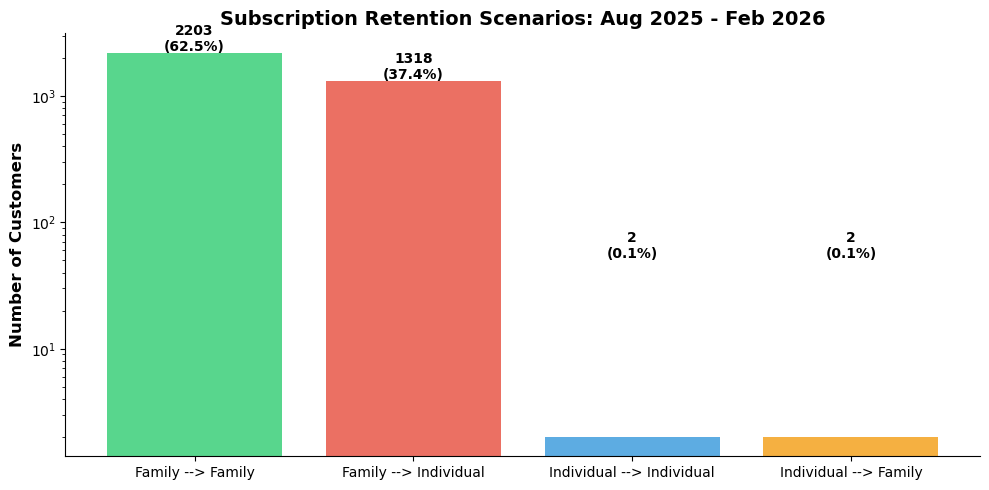

In [56]:
# Prepare Data
scenario_names = ['Family --> Family', 'Family --> Individual', 
                  'Individual --> Individual', 'Individual --> Family']

scenario_counts = [len(family_to_family), len(family_to_individual),
                   len(indiv_to_indiv), len(indiv_to_family)]

scenario_percentages = [(len(family_to_family) / total_survivors) * 100,
                        (len(family_to_individual) / total_survivors) * 100,
                        (len(indiv_to_indiv) / total_survivors) * 100,
                        (len(indiv_to_family) / total_survivors) * 100]

# Define Colors for each scenario
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

# Bar Chart
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(scenario_names, scenario_counts, color=colors, alpha=0.8, linewidth=1.5)

# Add value labels on bars
for bar, count, pct in zip(bars, scenario_counts, scenario_percentages):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 50, f'{count}\n({pct:.1f}%)', ha='center', fontweight='bold')

# Use log scale for Y axis
ax.set_yscale('log') 

# Formatting
ax.set_ylabel('Number of Customers', fontsize=12, fontweight='bold')
ax.set_title('Subscription Retention Scenarios: Aug 2025 - Feb 2026', fontsize=14, fontweight='bold')

# Remove top and right grid
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/eda_02/graph1_bar.png', dpi=150, bbox_inches='tight')
plt.show()



### 3.2.3. Retention Metrics Cpmparison

In [ ]:
# Compare Family --> Famliy vs Family --> Individual survival patterns

# Calculate metrics for each scenario
metrics_names = ['Family --> Family', 'Family --> Individual', 
                'Individual --> Individual', 'Individual --> Family']

# Average monthly charge and tenure for each scenario
avg_charges = [
        family_to_family['MonthlyCharges'].mean(),
        family_to_individual['MonthlyCharges'].mean(),
        indiv_to_family['MonthlyCharges'].mean() if len(indiv_to_family) > 0 else 0,
        indiv_to_indiv['MonthlyCharges'].mean() if len(indiv_to_indiv) > 0 else 0
]

avg_tenure = [
    family_to_family['calculated_tenure'].mean(),
    family_to_individual['calculated_tenure'].mean(),
    indiv_to_indiv['calculated_tenure'].mean() if len(indiv_to_indiv) > 0 else 0,
    indiv_to_family['calculated_tenure'].mean() if len(indiv_to_family) > 0 else 0,
]


In [59]:
print(survivors.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'calculated_tenure', 'signup_date', 'past_monthly_charges', 'consistency_check', 'tenure_diff', 'charge_change', 'family_aug', 'family_feb', 'scenario']


In [60]:
print(survivors[['MonthlyCharges', 'past_monthly_charges', 'charge_change']].describe())
print("\n10 Samples:")
print(survivors[['MonthlyCharges', 'past_monthly_charges', 'charge_change', 'scenario']].head(10))

       MonthlyCharges  past_monthly_charges  charge_change
count     3525.000000           3525.000000    3525.000000
mean        64.058496             64.094677      -0.036181
std         31.153468             31.177481       0.898604
min         18.250000             17.300000      -7.890000
25%         25.850000             25.943750      -0.364583
50%         69.350000             69.444828      -0.013846
75%         90.300000             90.363194       0.317568
max        118.600000            119.264394       9.110000

10 Samples:
    MonthlyCharges  past_monthly_charges  charge_change               scenario
1            56.95             57.267187      -0.317187  Family --> Individual
3            42.30             41.824419       0.475581  Family --> Individual
6            89.10             88.585714       0.514286      Family --> Family
7            29.75             30.238889      -0.488889  Family --> Individual
8            56.15             56.259016      -0.109016      

In [61]:
print(family_to_individual['charge_change'].describe())
print(f"\nIncreased charge customers: {len(family_to_individual[family_to_individual['charge_change'] > 0])}")
print(f"decreased charge customer 고객: {len(family_to_individual[family_to_individual['charge_change'] < 0])}")

count    1318.000000
mean       -0.041072
std         1.014146
min        -4.771429
25%        -0.400000
50%        -0.009105
75%         0.344808
max         6.320000
Name: charge_change, dtype: float64

Increased charge customers: 650
decreased charge customer 고객: 667


#### 3.2.4. Churn Rate by Scenario
- Family Plan continuity is associated with an 8.4% lower churn rate
- Despite absorbing 1,318 migrated customers, the Individual plan group shows significantly weaker retention


<p>
<table>
    <thead>
        <tr>
            <th>Scenario</th>
            <th>Survived</th>
            <th>Churned</th>
            <th>Churn Rate</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td><strong>Family → Family</strong></td>
            <td>2,203</td>
            <td>430</td>
            <td><strong>16.3%</strong></td>
        </tr>
        <tr>
            <td><strong>Family → Individual</strong></td>
            <td>1,318</td>
            <td>427</td>
            <td><strong>24.5%</strong></td>
        </tr>
    </tbody>
</table>
<p>

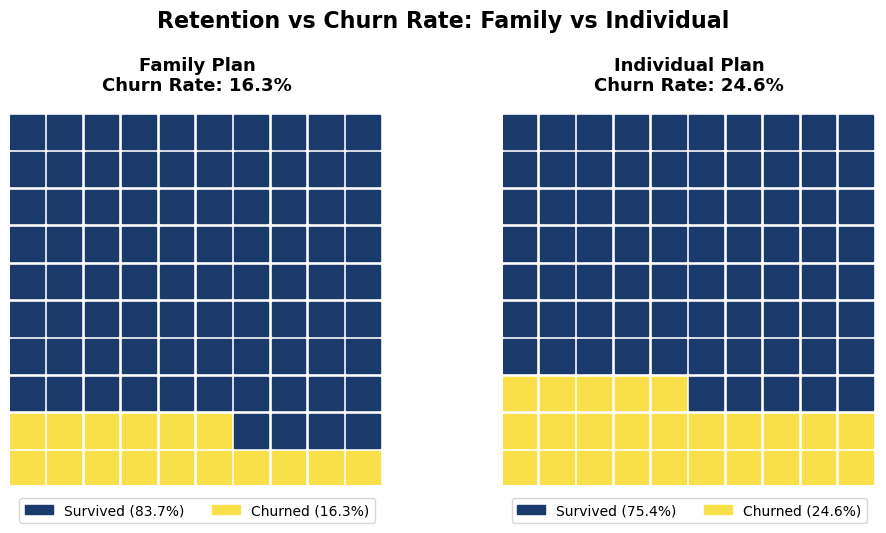

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Retention vs Churn Rate: Family vs Individual', 
             fontsize=16, fontweight='bold', y=1.02)

def draw_waffle(ax, churn_rate, survive_rate, title):
    data = np.zeros(100)
    data[:int(churn_rate)] = 1
    data = data.reshape(10, 10)
    
    for i in range(10):
        for j in range(10):
            color = '#f9e04b' if data[i][j] == 1 else '#1a3a6b'
            ax.add_patch(plt.Rectangle([j, i], 0.9, 0.9, color=color))
    
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'{title}\nChurn Rate: {churn_rate:.1f}%', 
                 fontsize=13, fontweight='bold', pad=15)
    
    patches = [mpatches.Patch(color='#1a3a6b', label=f'Survived ({survive_rate:.1f}%)'),
               mpatches.Patch(color='#f9e04b', label=f'Churned ({churn_rate:.1f}%)')]
    ax.legend(handles=patches, loc='lower center', 
              bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=10)

draw_waffle(axes[0], family_churn_rate, family_survive_rate, 'Stayed on Family Plan')
draw_waffle(axes[1], individual_churn_rate, individual_survive_rate, 'Migrated to Individual Plan')

plt.tight_layout()
plt.savefig('../outputs/eda_02/graph2_waffle.png', dpi=150, bbox_inches='tight')
plt.show()


#### 3.3. Tenure Distribution by Scenario
##### Tenure Distribution by Scenario ***(Boxplot)***
<p>
<table>
    <thead>
        <tr>
            <th>Scenario</th>
            <th>Median Tenure</th>
            <th>Mean Tenure</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td><strong>Family → Family</strong></td>
            <td>51 months</td>
            <td>47.3 months</td>
        </tr>
        <tr>
            <td><strong>Family → Individual</strong></td>
            <td>32 months</td>
            <td>35.4 months</td>
        </tr>
    </tbody>
</table>
</p>

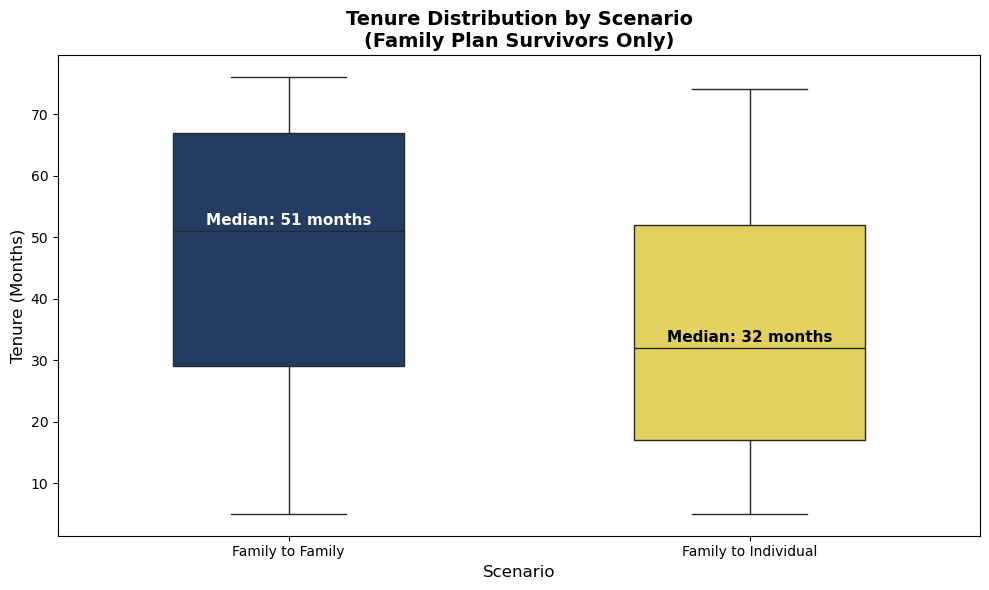

In [ ]:
#
box_data = survivors[survivors['scenario'].isin(['Family --> Family', 'Family --> Individual'])]


fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=box_data,
    x='scenario',
    y='tenure',
    hue='scenario',
    order=['Family --> Family', 'Family --> Individual'],
    palette={'Family --> Family': '#1a3a6b', 'Family --> Individual': '#f9e04b'},
    width=0.5,
    ax=ax
)

medians = box_data.groupby('scenario')['tenure'].median()

for i, scenario in enumerate(['Family --> Family', 'Family --> Individual']):
    ax.text(i, medians[scenario] + 1, f'Median: {medians[scenario]:.0f} months', 
            ha='center', fontsize=11, fontweight='bold',
            color='white' if scenario == 'Family --> Family' else 'black')
    

ax.set_title('Tenure Distribution by Scenario\n(Family Plan Survivors Only)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Scenario', fontsize=12)
ax.set_ylabel('Tenure (Months)', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Family to Family', 'Family to Individual'])

plt.tight_layout()
plt.savefig('../outputs/eda_02/graph3_tenure_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

##### NOTE:
- Family → Family survivors are 19 months longer-tenured at the median
- Longer tenure is a structural characteristic of the loyal segment, not a coincidence
- This supports the use of tenure as a resilience weight input in the price simulator

In [71]:
print(baseline[['scenario', 'Churn']].value_counts())

scenario                   Churn
Family --> Family          No       2203
Family --> Individual      No       1318
Individual --> Family      No          2
Individual --> Individual  No          2
Name: count, dtype: int64


### 4. Statistical Validation: Chi-Square Test

##### 4.1. Test Design
- Test: Chi-Square Test of Independence
- Variable 1: Scenario (Family → Family / Family → Individual) — Categorical
- Variable 2: Churn (Yes / No) — Categorical
- Question: Is the difference in churn rates between scenarios statistically significant, or could it be due to random chance?
<p>
<table>
    <thead>
        <tr>
            <th>Metric</th>
            <th>Value</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td><strong>Chi-Square Statistic</strong></td>
            <td>52.97</td>
        </tr>
        <tr>
            <td><strong>p-value</strong></td>
            <td>&lt; 0.001</td>
        </tr>
        <tr>
            <td><strong>Degrees of Freedom</strong></td>
            <td>3</td>
        </tr>
        <tr>
            <td><strong>Result</strong></td>
            <td>✅ Statistically Significant</td>
        </tr>
    </tbody>
</table>

#### Key Finding
- p-value < 0.001 confirms that the churn rate difference between Family → Family and Family → Individual is not due to random chance
- The relationship between scenario and churn outcome is statistically robust

In [77]:
# Chi-square
from scipy.stats import chi2_contingency

# Combine survivors and churners
all_data = pd.concat([survivors, churners])

# Contingency table (Family scenario Only)
ct = pd.crosstab(all_data['scenario'], all_data['Churn'])
print(ct)

chi2, p, dof, expected = chi2_contingency(ct)

print(f"\nChi-square statistic: {chi2:.4f}")
print(f"p-value: {p:.6f}")
print(f"Degrees of freedom: {dof}")


0.05673758865248227

Chi-square statistic: 52.9722
p-value: 0.000000
Degrees of freedom: 3


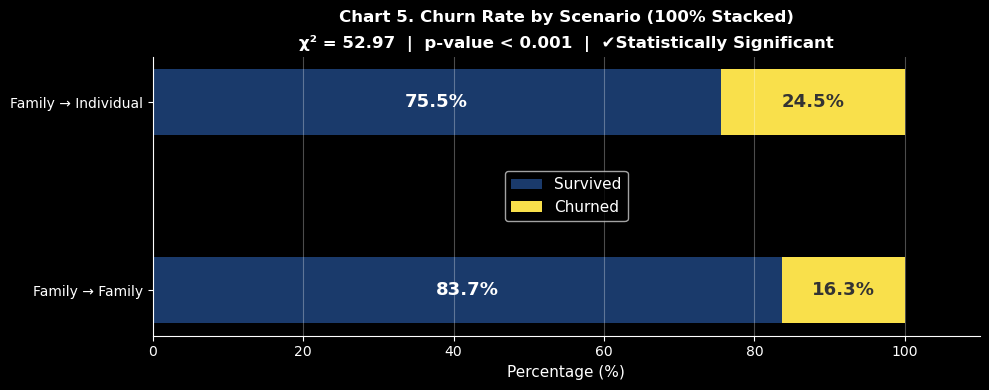

In [89]:
# Calculate from actual data
scenario_stats = all_data.groupby('scenario')['Churn'].value_counts(normalize=True).mul(100).unstack()
scenario_stats = scenario_stats.loc[['Family --> Family', 'Family --> Individual']]

survived_pct = scenario_stats['No'].values
churned_pct = scenario_stats['Yes'].values
scenarios = ['Family → Family', 'Family → Individual']

plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(10, 4))

# Horizontal stacked bars
ax.barh(scenarios, survived_pct, color='#1a3a6b', label='Survived', height=0.35)
ax.barh(scenarios, churned_pct, left=survived_pct, color='#f9e04b', label='Churned', height=0.35)

# Labels inside bars
for i in range(len(scenarios)):
    ax.text(survived_pct[i]/2, i, f'{survived_pct[i]:.1f}%',
            ha='center', va='center', fontsize=13, color='white', fontweight='bold')
    ax.text(survived_pct[i] + churned_pct[i]/2, i, f'{churned_pct[i]:.1f}%',
            ha='center', va='center', fontsize=13, color='#333333', fontweight='bold')


# Chi-square as subtitle
ax.set_title('Chart 5. Churn Rate by Scenario (100% Stacked)\nχ² = 52.97  |  p-value < 0.001  |  ✔️Statistically Significant',
             fontsize=12, fontweight='bold', linespacing=1.8)

ax.set_xlabel('Percentage (%)', fontsize=11)
ax.set_xlim(0, 110)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc= 'center', fontsize=11)
ax.grid(axis='x', alpha=0.3)


plt.tight_layout()
plt.savefig('../outputs/eda_02/graph4_chisquare_stacked.png', dpi=150, bbox_inches='tight')
plt.show()


## Conclusion — Hypothesis 2 Validated

- Customers who maintained Family Plan status through the Q3 2025 policy shift demonstrate structurally lower churn sensitivity
- This behavioral difference is statistically confirmed and not attributable to random variance

### Key Evidence

- **Churn Rate Gap:** Family → Family (16.3%) vs Family → Individual (24.5%) — 8.4 percentage point difference
- **Tenure Gap:** Family → Family median tenure is 19 months longer than Family → Individual (51 vs 32 months)
- **Statistical Validation:** Chi-Square test confirms the difference is significant (χ² = 52.97, p < 0.001)

### Business Implications

- **Resilience Segmentation:** Family plan customers represent a structurally more loyal segment and should be weighted differently in churn probability models
- **Migration Risk:** The 1,318 customers forced from Family → Individual plans represent an elevated churn risk cohort requiring targeted retention intervention
- **Price Sensitivity Input:** Family → Family customers can tolerate a higher price increase threshold before hitting a churn inflection point

### Recommendations

- Assign differentiated **resilience weights** to Family → Family vs Family → Individual segments in the price risk simulator
- Prioritize retention campaigns for the Family → Individual cohort during any future price adjustment cycles
- Consider **family plan re-qualification pathways** to reduce forced migration churn risk
